# CELL 0 : Setup + Constants


In [10]:
import sys, json, random, warnings
from pathlib import Path
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if device.type == 'cuda':
    print(f'  GPU  : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
else:
    print('  ⚠️  No GPU — switch runtime before training')

from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT  = Path('/content/drive/MyDrive/CropClassifier_v2')
DATA_ROOT   = Path('/content/dataset/resized_256')
MINI_DIR    = Path('/content/mini_disease')
MINI_DIR.mkdir(parents=True, exist_ok=True)

MODEL_DIR   = DRIVE_ROOT / 'models' / 'stage2_disease'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MINI_TRAIN  = MINI_DIR / 'train_mini.csv'
MINI_VAL    = MINI_DIR / 'val_mini.csv'
MINI_TEST   = MINI_DIR / 'test_mini.csv'

CROP_DISEASE_MAP = MODEL_DIR / 'crop_disease_map.json'
CLASS_TO_IDX     = MODEL_DIR / 'class_to_idx.json'


MODEL_NAME       = 'efficientnet_b0'
NUM_CLASSES      = None
TRAIN_PER_CLASS  = 30
VAL_PER_CLASS    = 8
TEST_PER_CLASS   = 8

IMG_SIZE         = 224
NORM_MEAN        = (0.5, 0.5, 0.5)
NORM_STD         = (0.5, 0.5, 0.5)

BATCH_SIZE       = 64
NUM_WORKERS      = 4
DROPOUT          = 0.3
LABEL_SMOOTHING  = 0.1
EPOCHS           = 20
LR               = 1e-3
WEIGHT_DECAY     = 1e-4

# Excludes: tea, cotton, wheat, corn, sugarcane, pineapple,
#           jute, blueberry, raspberry, orange, squash, onion, coffee, coconut
INCLUDED_CROPS = {
    'apple', 'tomato', 'potato', 'grape', 'groundnut',
    'lemon', 'mango', 'chilli', 'blackgram', 'bell_pepper',
    'cherry', 'dragon_fruit', 'soybean', 'strawberry',
    'peach', 'snake_gourd', 'bean', 'paddy',
}

print(f'\n✅  Setup complete')
print(f'    Stage        : 2 — Disease Classification')
print(f'    Crops        : {len(INCLUDED_CROPS)}')
print(f'    Model        : {MODEL_NAME}')
print(f'    Samples/class: {TRAIN_PER_CLASS} train | {VAL_PER_CLASS} val | {TEST_PER_CLASS} test')

Device : cuda
  GPU  : Tesla T4
  VRAM : 15.6 GB
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✅  Setup complete
    Stage        : 2 — Disease Classification
    Crops        : 18
    Model        : efficientnet_b0
    Samples/class: 30 train | 8 val | 8 test


# CELL 1 : Data Extraction + Soybean Restore
Same as Stage 1 — skip if images already on disk.

In [2]:
import zipfile
from pathlib import Path

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}

# Check if already extracted
data_ok   = DATA_ROOT.exists() and sum(
    1 for p in DATA_ROOT.iterdir() if p.is_dir()) > 10
soy_ok    = (DATA_ROOT / 'soybean').exists() and \
            len(list((DATA_ROOT / 'soybean').iterdir())) >= 2800

if data_ok and soy_ok:
    n_folders = sum(1 for p in DATA_ROOT.iterdir() if p.is_dir())
    n_soy     = len(list((DATA_ROOT / 'soybean').iterdir()))
    print(f'✅  Data already on disk')
    print(f'    {n_folders} crop folders | soybean: {n_soy:,} files')
    print(f'    Skipping extraction — delete /content/dataset to force re-extract')

else:
    # Step 1: Extract main dataset
    print('Extracting main dataset (this takes ~5-10 mins)...')
    !cat /content/drive/MyDrive/disease_detection/resized_part_* > /content/resized_256.zip
    !unzip -q -o /content/resized_256.zip -d /content/dataset -x "__MACOSX/*" "*/._*"
    print('✅  Main dataset extracted')

    # Step 2: Restore merged soybean from Drive backup
    print('Restoring soybean from Drive backup...')
    MERGED_DIR  = DATA_ROOT / 'soybean'
    MERGED_DIR.mkdir(parents=True, exist_ok=True)
    backup_zip  = DRIVE_ROOT / 'soybean_merged_backup.zip'

    if not backup_zip.exists():
        print('  ⚠️  soybean_merged_backup.zip not found on Drive')
        print('      Run the soybean merge cell from Stage 1 first')
    else:
        with zipfile.ZipFile(backup_zip, 'r') as zf:
            zf.extractall(MERGED_DIR)
        n_soy = len(list(MERGED_DIR.iterdir()))
        print(f'✅  Soybean restored: {n_soy:,} files')


print(f'\nDataset verification:')
missing = []
for crop_folder in sorted(DATA_ROOT.iterdir()):
    if not crop_folder.is_dir():
        continue
    n_imgs = sum(1 for f in crop_folder.rglob('*')
                 if f.suffix.lower() in IMG_EXTS)
    print(f'  {crop_folder.name:<55} {n_imgs:>7,}')
    if n_imgs == 0:
        missing.append(crop_folder.name)

if missing:
    print(f'\n⚠️  Empty folders: {missing}')
else:
    print(f'\n✅  All folders have images')

Extracting main dataset (this takes ~5-10 mins)...
✅  Main dataset extracted
Restoring soybean from Drive backup...
✅  Soybean restored: 2,815 files

Dataset verification:
  An_India_soyabean_leaf_dataset                            1,166
  Apple                                                     9,714
  Bean Health and Disease Dataset A Resource for Agr        3,528
  Blackgram_Plant_Leaf_Disease_Dataset                      1,007
  Blueberry                                                 2,270
  Cherry_(including_sour)                                   4,386
  Coconut Tree Disease Dataset-2                            5,798
  Corn_(maize)                                              9,145
  Cotton_Leaf                                                 132
  Dataset_of_groundnut_plant_leaf_images_for_classification_and_detection  10,356
  Dragon Fruit (Pitahaya)                                     724
  Grape                                                     9,027
  JMuBEN Arabica    

# CELL 2 : Disease Manifest Builder

In [3]:
import json
import numpy as np
import pandas as pd
from pathlib import Path

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}

FOLDER_TO_CROP = {
    'Apple'                                                                   : 'apple',
    'Bean Health and Disease Dataset A Resource for Agr'                      : 'bean',
    'Blackgram_Plant_Leaf_Disease_Dataset'                                    : 'blackgram',
    'Cherry_(including_sour)'                                                 : 'cherry',
    'Corn_(maize)'                                                            : 'corn',
    'Dataset_of_groundnut_plant_leaf_images_for_classification_and_detection' : 'groundnut',
    'Dragon Fruit (Pitahaya)'                                                 : 'dragon_fruit',
    'Grape'                                                                   : 'grape',
    'LLD_Lemon Leaf Dataset'                                                  : 'lemon',
    'Mango_Leaf_Disease_Dataset'                                              : 'mango',
    'Pepper,_bell'                                                            : 'bell_pepper',
    'Potato'                                                                  : 'potato',
    'Snake Gourd-Dataset'                                                     : 'snake_gourd',
    'Strawberry'                                                              : 'strawberry',
    'Peach'                                                                   : 'peach',
    'Tomato'                                                                  : 'tomato',
    'chilli_dataset'                                                          : 'chilli',
    'paddy-disease-classification'                                            : 'paddy',
    'An_India_soyabean_leaf_dataset'                                          : 'soybean',
    'Blueberry'                                                               : 'blueberry',
    'Raspberry'                                                               : 'raspberry',
}


DISEASE_LABEL_MAP = {
    # apple
    'Apple_scab'                                      : 'apple__scab',
    'Black_rot'                                       : '_black_rot',         # also in Grape — generic
    'Cedar_apple_rust'                                : 'apple__cedar_rust',
    'healthy'                                         : '_healthy',           # generic across many crops

    # bean
    'Angular-Leaf-Spot'                               : 'bean__angular_leaf_spot',
    'Bacterial Pathogen'                              : 'bean__bacterial_pathogen',
    'Cercospora-Leaf-Spot'                            : 'bean__cercospora_leaf_spot',
    'Fungi-Pathogens'                                 : 'bean__fungi_pathogens',
    'Good Leaves'                                     : 'bean__healthy',
    'Halo-Blight'                                     : 'bean__halo_blight',
    'No Disease Bean'                                 : 'bean__healthy',      # merge with Good Leaves
    'Potassium-Deficiency'                            : 'bean__potassium_deficiency',
    'tobacco_caterpillar'                             : 'bean__tobacco_caterpillar',
    'yellow_mosaic'                                   : 'bean__yellow_mosaic',

    # blackgram
    'Anthracnose 230'                                 : 'blackgram__anthracnose',
    'Healthy 220'                                     : 'blackgram__healthy',
    'Leaf Crinckle 150'                                : 'blackgram__leaf_crinkle',
    'Powdery Mildew 180'                              : 'blackgram__powdery_mildew',
    'Yellow Mosaic 220'                               : 'blackgram__yellow_mosaic',

    # cherry
    'Powdery_mildew'                                  : 'cherry__powdery_mildew',

    # dragon_fruit
    'Anthracnose'                                     : '_anthracnose',       # also in Snake Gourd — generic
    'Brown_Stem_Spot'                                 : 'dragon_fruit__brown_stem_spot',
    'Gray_Blight'                                     : 'dragon_fruit__gray_blight',
    'Soft_Rot'                                        : 'dragon_fruit__soft_rot',
    'Stem_Canker'                                     : 'dragon_fruit__stem_canker',

    # grape
    'Esca_(Black_Measles)'                            : 'grape__esca',
    'Leaf_blight_(Isariopsis_Leaf_Spot)'              : 'grape__leaf_blight',

    # groundnut
    'early_leaf_spot_1'                               : 'groundnut__early_leaf_spot',
    'early_rust_1'                                    : 'groundnut__early_rust',
    'healthy_leaf_1'                                  : 'groundnut__healthy',
    'late_leaf_spot_1'                                : 'groundnut__late_leaf_spot',
    'nutrition_deficiency_1'                          : 'groundnut__nutrition_deficiency',
    'rust_1'                                          : 'groundnut__rust',

    # lemon
    'Algal_Leaf_Spot'                                 : 'lemon__algal_leaf_spot',
    'Black_Spot'                                      : 'lemon__black_spot',
    'Citrus_Canker'                                   : 'lemon__citrus_canker',
    'Citrus_Pest'                                     : 'lemon__citrus_pest',
    'Citrus_Scab'                                     : 'lemon__citrus_scab',
    'Greening'                                        : 'lemon__greening',
    'Healthy_Leaf'                                    : 'lemon__healthy',
    'Leaf_Curl'                                       : 'lemon__leaf_curl',
    'Yellow_Spot'                                     : 'lemon__yellow_spot',

    # mango
    'Bacterial Canker'                                : 'mango__bacterial_canker',
    'Cutting Weevil'                                  : 'mango__cutting_weevil',
    'Die Back'                                        : 'mango__die_back',
    'Gall Midge'                                      : 'mango__gall_midge',
    'Powdery Mildew'                                  : 'mango__powdery_mildew',
    'Sooty Mould'                                     : 'mango__sooty_mould',

    # bell_pepper / peach / tomato share this literal subfolder name
    'Bacterial_spot'                                  : '_bacterial_spot',    # generic

    # potato / tomato share these literal subfolder names
    'Early_blight'                                    : '_early_blight',      # generic
    'Late_blight'                                     : '_late_blight',       # generic

    # snake_gourd
    'Yellow'                                          : 'snake_gourd__yellow_mosaic',

    # soybean (India dataset)
    'Bacterial_leaf_Blight'                           : 'soybean__bacterial_leaf_blight',
    'Dry_leaf'                                        : 'soybean__dry_leaf',
    'Healthy'                                         : '_healthy',           # generic
    'Septoria_Brown_Spot'                             : 'soybean__septoria_brown_spot',
    'Vein_Necrosis'                                   : 'soybean__vein_necrosis',

    # strawberry
    'Leaf_scorch'                                     : 'strawberry__leaf_scorch',

    # tomato (unique ones only — early/late blight, bacterial_spot handled generically above)
    'Leaf_Mold'                                       : 'tomato__leaf_mold',
    'Septoria_leaf_spot'                              : 'tomato__septoria_leaf_spot',
    'Spider_mites Two-spotted_spider_mite'            : 'tomato__spider_mites',
    'Target_Spot'                                     : 'tomato__target_spot',
    'Tomato_Yellow_Leaf_Curl_Virus'                   : 'tomato__yellow_leaf_curl_virus',
    'Tomato_mosaic_virus'                             : 'tomato__mosaic_virus',

    # chilli
    'cerocospora'                                     : 'chilli__cercospora',
    'murda complex'                                   : 'chilli__murda_complex',
    'nutritional deficiency'                          : 'chilli__nutritional_deficiency',
    'powdery mildew'                                  : 'chilli__powdery_mildew',

    # paddy
    'bacterial_leaf_blight'                           : 'paddy__bacterial_leaf_blight',
    'bacterial_leaf_streak'                           : 'paddy__bacterial_leaf_streak',
    'bacterial_panicle_blight'                        : 'paddy__bacterial_panicle_blight',
    'blast'                                           : 'paddy__blast',
    'brown_spot'                                      : 'paddy__brown_spot',
    'dead_heart'                                      : 'paddy__dead_heart',
    'downy_mildew'                                    : 'paddy__downy_mildew',
    'hispa'                                           : 'paddy__hispa',
    'normal'                                          : 'paddy__healthy',
    'tungro'                                          : 'paddy__tungro',
}

NEEDS_PREFIX = {
    '_healthy',
    '_anthracnose',
    '_bacterial_spot',
    '_black_rot',
    '_early_blight',
    '_late_blight',
}

def resolve_label(crop, subfolder_name):
    """
    Resolves subfolder name to canonical disease label.
    Handles generic labels that need crop prefix.
    Falls back to crop__subfolder_normalized if not in map.
    """
    raw = DISEASE_LABEL_MAP.get(subfolder_name)

    if raw is None:
        normalized = subfolder_name.lower().strip().replace(' ', '_')
        return f'{crop}__{normalized}'

    if raw in NEEDS_PREFIX:
        return f'{crop}__{raw.lstrip("_")}'

    return raw


records      = []
skipped      = []
label_issues = []

for folder in sorted(DATA_ROOT.iterdir()):
    if not folder.is_dir():
        continue

    crop = FOLDER_TO_CROP.get(folder.name)
    if crop is None or crop not in INCLUDED_CROPS:
        continue

    subfolders = [p for p in folder.iterdir() if p.is_dir()]
    if not subfolders:
        skipped.append((folder.name, 'no subfolders'))
        continue

    crop_records = 0
    for sub in sorted(subfolders):
        disease_label = resolve_label(crop, sub.name)
        imgs = [p for p in sub.rglob('*') if p.suffix.lower() in IMG_EXTS]

        if len(imgs) < 20:
            label_issues.append(
                f'  ⚠️  {crop}/{sub.name} → {disease_label}: only {len(imgs)} images (keeping)'
            )

        for img_path in imgs:
            records.append({
                'filepath' : str(img_path.relative_to(DATA_ROOT)),
                'crop'     : crop,
                'disease'  : disease_label,
            })
            crop_records += 1

    print(f'  ✅  {folder.name:<55} → {crop:<15} ({crop_records:,} imgs)')

if skipped:
    print(f'\nSkipped (no subfolders):')
    for name, reason in skipped:
        print(f'  {name}: {reason}')

if label_issues:
    print(f'\nSmall class warnings:')
    for w in label_issues:
        print(w)

df = pd.DataFrame(records)
print(f'\n{"─"*55}')
print(f'  Total images   : {len(df):,}')
print(f'  Crops          : {df["crop"].nunique()}')
print(f'  Disease classes: {df["disease"].nunique()}')


print(f'\n── Cross-crop label leakage check ──')
leak_found = False
for _, row in df.iterrows():
    if not row['disease'].startswith(f"{row['crop']}__"):
        print(f'  🔴  LEAK: crop={row["crop"]}  disease={row["disease"]}  file={row["filepath"]}')
        leak_found = True
        break  # just show first occurrence, rest handled by groupby below

leak_summary = (
    df.assign(expected_prefix=df['crop'] + '__')
      .loc[lambda d: ~d.apply(lambda r: r['disease'].startswith(r['expected_prefix']), axis=1)]
)
if len(leak_summary):
    print(f'  🔴  {len(leak_summary)} rows have mismatched crop/disease prefixes:')
    print(leak_summary[['crop', 'disease']].drop_duplicates())
    raise SystemExit('Stopping: fix DISEASE_LABEL_MAP / NEEDS_PREFIX before proceeding')
else:
    print(f'  ✅  No leakage — every disease label matches its crop prefix')


print(f'\nPer-crop disease breakdown:')
for crop in sorted(df["crop"].unique()):
    crop_df  = df[df["crop"] == crop]
    diseases = crop_df["disease"].unique()
    n_imgs   = len(crop_df)
    print(f'\n  {crop} ({n_imgs:,} images, {len(diseases)} classes):')
    for d in sorted(diseases):
        n = (crop_df["disease"] == d).sum()
        flag = '  ⚠️ small' if n < 100 else ''
        print(f'    {d:<55} {n:>5}{flag}')

def stratified_split(df, label_col='disease',
                     train_frac=0.70, val_frac=0.15, seed=SEED):
    rng = np.random.default_rng(seed)
    train_rows, val_rows, test_rows = [], [], []
    for cls, group in df.groupby(label_col):
        idx = group.index.to_numpy().copy()
        rng.shuffle(idx)
        n       = len(idx)
        n_train = max(1, int(round(n * train_frac)))
        n_val   = max(1, min(int(round(n * val_frac)), n - n_train))
        train_rows.append(group.loc[idx[:n_train]])
        val_rows.append(group.loc[idx[n_train:n_train+n_val]])
        test_rows.append(group.loc[idx[n_train+n_val:]])
    return (pd.concat(train_rows).reset_index(drop=True),
            pd.concat(val_rows).reset_index(drop=True),
            pd.concat(test_rows).reset_index(drop=True))

train_df, val_df, test_df = stratified_split(df)

print(f'\n{"─"*55}')
print(f'  Train : {len(train_df):,}')
print(f'  Val   : {len(val_df):,}')
print(f'  Test  : {len(test_df):,}')


sorted_diseases = sorted(df['disease'].unique())
class_to_idx    = {d: i for i, d in enumerate(sorted_diseases)}
NUM_CLASSES     = len(class_to_idx)
print(f'\n  NUM_CLASSES set to: {NUM_CLASSES}')


crop_disease_map = {}
for crop in sorted(df['crop'].unique()):
    diseases = sorted(df[df['crop'] == crop]['disease'].unique().tolist())
    crop_disease_map[crop] = diseases


train_df.to_csv(DRIVE_ROOT / 'disease_train_manifest.csv', index=False)
val_df.to_csv(DRIVE_ROOT   / 'disease_val_manifest.csv',   index=False)
test_df.to_csv(DRIVE_ROOT  / 'disease_test_manifest.csv',  index=False)

with open(CROP_DISEASE_MAP, 'w') as f:
    json.dump(crop_disease_map, f, indent=2)

with open(CLASS_TO_IDX, 'w') as f:
    json.dump(class_to_idx, f, indent=2)

print(f'\n✅  Saved to Drive:')
print(f'    disease_train_manifest.csv')
print(f'    disease_val_manifest.csv')
print(f'    disease_test_manifest.csv')
print(f'    crop_disease_map.json  ({len(crop_disease_map)} crops)')
print(f'    class_to_idx.json      ({NUM_CLASSES} disease classes)')

  ✅  An_India_soyabean_leaf_dataset                          → soybean         (1,166 imgs)
  ✅  Apple                                                   → apple           (9,714 imgs)
  ✅  Bean Health and Disease Dataset A Resource for Agr      → bean            (3,528 imgs)
  ✅  Blackgram_Plant_Leaf_Disease_Dataset                    → blackgram       (1,007 imgs)
  ✅  Cherry_(including_sour)                                 → cherry          (4,386 imgs)
  ✅  Dataset_of_groundnut_plant_leaf_images_for_classification_and_detection → groundnut       (10,356 imgs)
  ✅  Dragon Fruit (Pitahaya)                                 → dragon_fruit    (724 imgs)
  ✅  Grape                                                   → grape           (9,027 imgs)
  ✅  LLD_Lemon Leaf Dataset                                  → lemon           (4,675 imgs)
  ✅  Mango_Leaf_Disease_Dataset                              → mango           (2,353 imgs)
  ✅  Peach                                                   → pe

# CELL 3 : Subsample Mini Manifests


In [4]:

# Pulls from Drive manifests, caps at N per disease class.

import pandas as pd
import json
from pathlib import Path

# Reload class map in case of reconnect
with open(CLASS_TO_IDX) as f:
    class_to_idx = json.load(f)
with open(CROP_DISEASE_MAP) as f:
    crop_disease_map = json.load(f)

NUM_CLASSES  = len(class_to_idx)
idx_to_class = {v: k for k, v in class_to_idx.items()}

print(f'Loaded: {NUM_CLASSES} disease classes across {len(crop_disease_map)} crops')


def subsample(csv_path, n_per_class, seed=SEED):
    df = pd.read_csv(csv_path)
    return (df.groupby('disease', group_keys=False)
              .apply(lambda g: g.sample(min(len(g), n_per_class),
                                        random_state=seed))
              .reset_index(drop=True))

train_df = subsample(DRIVE_ROOT / 'disease_train_manifest.csv', TRAIN_PER_CLASS)
val_df   = subsample(DRIVE_ROOT / 'disease_val_manifest.csv',   VAL_PER_CLASS)
test_df  = subsample(DRIVE_ROOT / 'disease_test_manifest.csv',  TEST_PER_CLASS)

train_df.to_csv(MINI_TRAIN, index=False)
val_df.to_csv(MINI_VAL,     index=False)
test_df.to_csv(MINI_TEST,   index=False)

print(f'\n✅  Mini manifests saved')
print(f'    Train : {len(train_df):,}  ({train_df["disease"].nunique()} classes)')
print(f'    Val   : {len(val_df):,}')
print(f'    Test  : {len(test_df):,}')


print(f'\nPer-class train counts (small classes flagged):')
counts      = train_df['disease'].value_counts().sort_index()
below_cap   = counts[counts < TRAIN_PER_CLASS]
at_cap      = counts[counts >= TRAIN_PER_CLASS]

print(f'  At cap ({TRAIN_PER_CLASS}): {len(at_cap)} classes')
if len(below_cap):
    print(f'  Below cap:')
    for cls, n in below_cap.items():
        print(f'    {cls:<55} {n:>3} images available')

Loaded: 95 disease classes across 18 crops

✅  Mini manifests saved
    Train : 2,850  (95 classes)
    Val   : 760
    Test  : 760

Per-class train counts (small classes flagged):
  At cap (30): 95 classes


# CELL 4 : Transforms


In [5]:
# Single pipeline — no bg routing needed for disease classifier.
# Resize→crop covers images at any stored size.

!pip install -q albumentations

import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

train_transform = A.Compose([
    A.Resize(256, 256, interpolation=cv2.INTER_CUBIC),
    A.RandomCrop(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=20, p=0.5, border_mode=cv2.BORDER_REFLECT),
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25),
        A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=30, val_shift_limit=20),
        A.RGBShift(r_shift_limit=15, g_shift_limit=15, b_shift_limit=15),
    ], p=0.7),
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 5)),
        A.GaussNoise(),
        A.ImageCompression(quality_range=(40, 95)),
    ], p=0.3),
    A.CoarseDropout(
        num_holes_range=(1, 4),
        hole_height_range=(8, 20),
        hole_width_range=(8, 20),
        p=0.25,
    ),
    A.Normalize(mean=NORM_MEAN, std=NORM_STD),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(256, 256, interpolation=cv2.INTER_CUBIC),
    A.CenterCrop(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=NORM_MEAN, std=NORM_STD),
    ToTensorV2(),
])

print('✅  Transforms built: train_transform, val_transform')

✅  Transforms built: train_transform, val_transform


# CELL 5 : Dataset + DataLoaders + Loss


In [6]:
# Crop-aware: knows which diseases belong to which crop.

import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from pathlib import Path

# Reload from Drive in case of reconnect
with open(CLASS_TO_IDX) as f:
    class_to_idx = json.load(f)
with open(CROP_DISEASE_MAP) as f:
    crop_disease_map = json.load(f)

NUM_CLASSES  = len(class_to_idx)
idx_to_class = {v: k for k, v in class_to_idx.items()}

print(f'Loaded: {NUM_CLASSES} disease classes across {len(crop_disease_map)} crops')

# Dataset
class DiseaseDataset(Dataset):
    def __init__(self, csv_path, data_root, class_to_idx, transform):
        self.df           = pd.read_csv(csv_path)
        self.data_root    = Path(data_root)
        self.class_to_idx = class_to_idx
        self.transform    = transform
        self.labels       = self.df['disease'].map(class_to_idx).to_numpy()

        unknown = set(self.df['disease'].unique()) - set(class_to_idx)
        assert not unknown, f'Unknown disease labels in manifest: {unknown}'

        missing = self.df['disease'].map(class_to_idx).isna().sum()
        assert missing == 0, f'{missing} rows have unmapped disease labels'

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = np.array(
            Image.open(self.data_root / row['filepath']).convert('RGB')
        )
        img = self.transform(image=img)['image']
        return img, int(self.labels[idx])

    def get_labels(self):
        return self.labels

    def get_crop_for_idx(self, idx):
        return self.df.iloc[idx]['crop']


# Build datasets
train_ds = DiseaseDataset(MINI_TRAIN, DATA_ROOT, class_to_idx, train_transform)
val_ds   = DiseaseDataset(MINI_VAL,   DATA_ROOT, class_to_idx, val_transform)
test_ds  = DiseaseDataset(MINI_TEST,  DATA_ROOT, class_to_idx, val_transform)

# Weighted CE — handles severe disease class imbalance
class_counts = np.bincount(
    train_ds.get_labels(), minlength=NUM_CLASSES
).clip(1)
weights = torch.tensor(
    class_counts.sum() / (NUM_CLASSES * class_counts),
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=weights,
    label_smoothing=LABEL_SMOOTHING
)

# DataLoaders
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True,
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True,
)

# Sanity check
imgs, labels = next(iter(train_loader))
print(f'\n✅  DataLoaders ready')
print(f'    Train        : {len(train_ds):,} samples')
print(f'    Val          : {len(val_ds):,} samples')
print(f'    Test         : {len(test_ds):,} samples')
print(f'    Batch shape  : {tuple(imgs.shape)}')
print(f'    Steps/epoch  : {len(train_loader)}')
print(f'    Class weight range: {weights.min():.3f} – {weights.max():.3f}')

# Per-crop label distribution check
print(f'\nPer-crop disease distribution in train split:')
df_check = pd.read_csv(MINI_TRAIN)
for crop in sorted(df_check['crop'].unique()):
    diseases = df_check[df_check['crop'] == crop]['disease'].value_counts()
    print(f'\n  {crop} ({len(diseases)} classes):')
    for disease, n in diseases.items():
        flag = '  ⚠️' if n < TRAIN_PER_CLASS else ''
        print(f'    {disease:<55} {n:>3}{flag}')

Loaded: 95 disease classes across 18 crops

✅  DataLoaders ready
    Train        : 2,850 samples
    Val          : 760 samples
    Test         : 760 samples
    Batch shape  : (64, 3, 224, 224)
    Steps/epoch  : 45
    Class weight range: 1.000 – 1.000

Per-crop disease distribution in train split:

  apple (4 classes):
    apple__black_rot                                         30
    apple__cedar_rust                                        30
    apple__healthy                                           30
    apple__scab                                              30

  bean (9 classes):
    bean__angular_leaf_spot                                  30
    bean__bacterial_pathogen                                 30
    bean__cercospora_leaf_spot                               30
    bean__fungi_pathogens                                    30
    bean__halo_blight                                        30
    bean__healthy                                            30
    bean__pot

# CELL 6 : Model — EfficientNet-B0 (Stage 2: Disease Classification)


In [7]:

import timm
import torch

model = timm.create_model(
    MODEL_NAME,          # 'efficientnet_b0'
    pretrained=True,
    num_classes=NUM_CLASSES,
    drop_rate=DROPOUT,
)
model = model.to(device)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'✅  Model built: {MODEL_NAME}')
print(f'    Num classes      : {NUM_CLASSES}')
print(f'    Total params     : {total_params/1e6:.2f}M')
print(f'    Trainable params : {trainable_params/1e6:.2f}M')


model.eval()
with torch.no_grad():
    imgs, labels = next(iter(train_loader))
    imgs = imgs.to(device)
    out  = model(imgs)

assert out.shape == (imgs.shape[0], NUM_CLASSES), \
    f'Unexpected output shape: {out.shape}, expected (*, {NUM_CLASSES})'

print(f'    Forward pass OK  : input {tuple(imgs.shape)} → output {tuple(out.shape)}')


assert NUM_CLASSES == len(class_to_idx), \
    f'Mismatch: model has {NUM_CLASSES} classes, class_to_idx has {len(class_to_idx)}'
print(f'    ✅  NUM_CLASSES matches class_to_idx.json ({len(class_to_idx)} classes)')

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

✅  Model built: efficientnet_b0
    Num classes      : 95
    Total params     : 4.13M
    Trainable params : 4.13M
    Forward pass OK  : input (64, 3, 224, 224) → output (64, 95)
    ✅  NUM_CLASSES matches class_to_idx.json (95 classes)


# CELL 7 : Train


In [11]:
# Single-phase, all layers unfrozen from the start.
# Saves best checkpoint to Drive by val macro F1.

import time
import torch
from sklearn.metrics import f1_score, accuracy_score
from tqdm.auto import tqdm

SAVE_MINI = MODEL_DIR / 'efficientnet_b0_disease_mini.pt'


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
                logits = model(imgs)
                loss   = criterion(logits, labels)
            total_loss += loss.item() * imgs.size(0)
            all_preds.extend(logits.argmax(1).cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
    n = len(all_labels)
    return (
        total_loss / n,
        accuracy_score(all_labels, all_preds),
        f1_score(all_labels, all_preds, average='macro',    zero_division=0),
        f1_score(all_labels, all_preds, average='weighted', zero_division=0),
    )


optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

best_macro_f1 = -1.0
history = []

print(f'Training {EPOCHS} epochs | {len(train_loader)} steps/epoch | batch {BATCH_SIZE}')
print(f'Classes: {NUM_CLASSES}  |  Model: {MODEL_NAME}')
print(f"{'Ep':>4}  {'TrLoss':>8}  {'TrAcc':>7}  {'VLoss':>8}  {'VAcc':>7}  {'M-F1':>7}  {'LR':>9}")
print('─' * 72)

for epoch in range(1, EPOCHS + 1):
    model.train()
    run_loss, correct, total = 0.0, 0, 0
    t0 = time.time()

    for imgs, labels in tqdm(train_loader, desc=f'Ep {epoch}/{EPOCHS}', leave=False):
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        run_loss += loss.item() * imgs.size(0)
        correct  += (logits.argmax(1) == labels).sum().item()
        total    += labels.size(0)

    scheduler.step()

    tr_loss, tr_acc          = run_loss / total, correct / total
    v_loss, v_acc, v_mf1, _  = evaluate(model, val_loader, criterion, device)
    cur_lr                   = scheduler.get_last_lr()[0]
    elapsed                  = time.time() - t0

    improved = v_mf1 > best_macro_f1
    if improved:
        best_macro_f1 = v_mf1
        torch.save({
            'epoch': epoch,
            'model_state': model.state_dict(),
            'val_macro_f1': v_mf1,
            'val_acc': v_acc,
            'class_to_idx': class_to_idx,   # bundled for standalone inference
        }, SAVE_MINI)

    flag = '✅' if improved else ''
    print(f'{epoch:>4}  {tr_loss:>8.4f}  {tr_acc:>7.4f}  {v_loss:>8.4f}  '
          f'{v_acc:>7.4f}  {v_mf1:>7.4f}  {cur_lr:>9.2e}  {flag}  ({elapsed:.0f}s)')

    history.append({
        'epoch': epoch, 'tr_loss': tr_loss, 'tr_acc': tr_acc,
        'v_loss': v_loss, 'v_acc': v_acc, 'v_macro_f1': v_mf1,
    })

print(f'\n✅  Best val macro F1: {best_macro_f1:.4f}  →  {SAVE_MINI}')

Training 20 epochs | 45 steps/epoch | batch 64
Classes: None  |  Model: efficientnet_b0
  Ep    TrLoss    TrAcc     VLoss     VAcc     M-F1         LR
────────────────────────────────────────────────────────────────────────


Ep 1/20:   0%|          | 0/45 [00:00<?, ?it/s]

   1    1.2761   0.8758    1.3719   0.8408   0.8308   9.94e-04  ✅  (49s)


Ep 2/20:   0%|          | 0/45 [00:00<?, ?it/s]

   2    1.2083   0.8947    1.3068   0.8526   0.8503   9.76e-04  ✅  (52s)


...

  18    0.8665   0.9877    1.1116   0.8908   0.8896   2.54e-05    (64s)


Ep 19/20:   0%|          | 0/45 [00:00<?, ?it/s]

  19    0.8588   0.9912    1.1117   0.8921   0.8910   7.15e-06    (52s)


Ep 20/20:   0%|          | 0/45 [00:00<?, ?it/s]

  20    0.8613   0.9909    1.1134   0.8921   0.8908   1.00e-06    (53s)

✅  Best val macro F1: 0.8957  →  /content/drive/MyDrive/CropClassifier_v2/models/stage2_disease/efficientnet_b0_disease_mini.pt


# CELL 8 : Test Set Evaluation


In [13]:
# Breaks down results per-crop AND per-disease since a crop with
# weak overall performance can still hide one strong disease class.

import torch
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, accuracy_score, confusion_matrix
from tqdm.auto import tqdm

ckpt = torch.load(SAVE_MINI, map_location=device)
model.load_state_dict(ckpt['model_state'])
model.eval()
print(f'Loaded: epoch {ckpt["epoch"]}  |  val macro F1 = {ckpt["val_macro_f1"]:.4f}')

all_preds, all_labels, all_crops = [], [], []
test_df = pd.read_csv(MINI_TEST)

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc='Testing'):
        preds = model(imgs.to(device)).argmax(1).cpu().tolist()
        all_preds.extend(preds)
        all_labels.extend(labels.tolist())

# test_loader is not shuffled, so this aligns 1:1 with test_df row order
all_crops = test_df['crop'].tolist()

acc      = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average='macro',    zero_division=0)
w_f1     = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print(f'\n── Overall Test Results ─────────────────────────')
print(f'  Accuracy    : {acc:.4f}')
print(f'  Macro F1    : {macro_f1:.4f}')
print(f'  Weighted F1 : {w_f1:.4f}')

gap = abs(acc - macro_f1)
if gap > 0.15:
    print(f'\n  ⚠️  Accuracy vs Macro F1 gap = {gap:.3f} — some classes are failing hard')

# Per-disease F1 (worst → best)
disease_f1s = f1_score(all_labels, all_preds, average=None, zero_division=0)
print(f'\n── Per-disease F1 (worst → best) ──')
for i, f1 in sorted(enumerate(disease_f1s), key=lambda x: x[1]):
    bar  = '█' * int(f1 * 20)
    flag = '  ⚠️' if f1 < 0.5 else ''
    print(f'  {idx_to_class[i]:<45} {f1:.3f}  {bar}{flag}')

# Per-crop accuracy (rolls disease-level results up to crop)
result_df = pd.DataFrame({
    'crop'   : all_crops,
    'true'   : [idx_to_class[l] for l in all_labels],
    'pred'   : [idx_to_class[p] for p in all_preds],
})
result_df['correct'] = result_df['true'] == result_df['pred']

crop_summary = result_df.groupby('crop').agg(
    n=('correct', 'count'),
    acc=('correct', 'mean'),
).sort_values('acc')

print(f'\n── Per-crop accuracy (worst → best) ──')
for crop, row in crop_summary.iterrows():
    flag = '  ⚠️' if row['acc'] < 0.5 else ''
    bar  = '█' * int(row['acc'] * 20)
    print(f'  {crop:<15} n={int(row["n"]):>3}  {row["acc"]:.3f}  {bar}{flag}')

# Top confused pairs (within-crop and cross-crop)
cm = confusion_matrix(all_labels, all_preds)
np.fill_diagonal(cm, 0)

pairs = []
num_classes_found = cm.shape[0]
for i in range(num_classes_found):
    for j in range(num_classes_found):
        if cm[i, j] > 0:
            total_i = (np.array(all_labels) == i).sum()
            pairs.append((idx_to_class[i], idx_to_class[j], cm[i, j], cm[i, j]/total_i*100))

pairs.sort(key=lambda x: x[2], reverse=True)
print(f'\n── Top-15 confused pairs (true → predicted) ──')
for true, pred, count, pct in pairs[:15]:
    cross_crop = '  ⚠️ CROSS-CROP' if true.split('__')[0] != pred.split('__')[0] else ''
    print(f'  {true:<45} → {pred:<45} {count:>3} errors ({pct:.0f}%){cross_crop}')

# Save full results to Drive for later reference
result_df.to_csv(DRIVE_ROOT / 'disease_mini_test_results.csv', index=False)
print(f'\n✅  Full results saved → disease_mini_test_results.csv')


Loaded: epoch 14  |  val macro F1 = 0.8957


Testing:   0%|          | 0/12 [00:00<?, ?it/s]


── Overall Test Results ─────────────────────────
  Accuracy    : 0.9105
  Macro F1    : 0.9102
  Weighted F1 : 0.9102

── Per-disease F1 (worst → best) ──
  chilli__healthy                               0.400  ████████  ⚠️
  chilli__cercospora                            0.444  ████████  ⚠️
  chilli__murda_complex                         0.533  ██████████
  paddy__brown_spot                             0.533  ██████████
  mango__anthracnose                            0.556  ███████████
  mango__bacterial_canker                       0.615  ████████████
  chilli__nutritional_deficiency                0.625  ████████████
  paddy__tungro                                 0.706  ██████████████
  paddy__blast                                  0.714  ██████████████
  paddy__hispa                                  0.714  ██████████████
  soybean__healthy                              0.737  ██████████████
  blackgram__healthy                            0.800  ████████████████
  mango__gall_midge 

# CELL 9 : Crop → Disease Masking Map


In [14]:
# Already built in Cell 2, but this cell verifies it against the
# trained model's class_to_idx and saves an inference-ready
# lookup (crop → list of valid class INDICES, not just names).

import json

with open(CROP_DISEASE_MAP) as f:
    crop_disease_map = json.load(f)
with open(CLASS_TO_IDX) as f:
    class_to_idx = json.load(f)

# ── Verify every disease in the map exists in class_to_idx ───────
all_mapped_diseases = set()
for crop, diseases in crop_disease_map.items():
    all_mapped_diseases.update(diseases)

missing = all_mapped_diseases - set(class_to_idx)
assert not missing, f'Diseases in crop_disease_map but not in class_to_idx: {missing}'

# ── Build index-based version for fast inference masking ─────────
crop_disease_idx_map = {
    crop: sorted([class_to_idx[d] for d in diseases])
    for crop, diseases in crop_disease_map.items()
}

CROP_DISEASE_IDX_MAP = MODEL_DIR / 'crop_disease_idx_map.json'
with open(CROP_DISEASE_IDX_MAP, 'w') as f:
    json.dump(crop_disease_idx_map, f, indent=2)

print(f'✅  Verified and saved crop_disease_idx_map.json')
print(f'\nCrop → number of valid disease classes:')
for crop in sorted(crop_disease_idx_map.keys()):
    n = len(crop_disease_idx_map[crop])
    print(f'  {crop:<15} {n:>2} classes')

print(f'\nTotal: {len(class_to_idx)} disease classes across {len(crop_disease_idx_map)} crops')

✅  Verified and saved crop_disease_idx_map.json

Crop → number of valid disease classes:
  apple            4 classes
  bean             9 classes
  bell_pepper      2 classes
  blackgram        5 classes
  cherry           2 classes
  chilli           5 classes
  dragon_fruit     6 classes
  grape            4 classes
  groundnut        6 classes
  lemon            9 classes
  mango            8 classes
  paddy           10 classes
  peach            2 classes
  potato           3 classes
  snake_gourd      3 classes
  soybean          5 classes
  strawberry       2 classes
  tomato          10 classes

Total: 95 disease classes across 18 crops


# CELL 10 : Standalone Disease Inference


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅  Model loaded — epoch 14 | val macro F1 = 0.8957
    Crop: tomato  →  10 valid disease classes


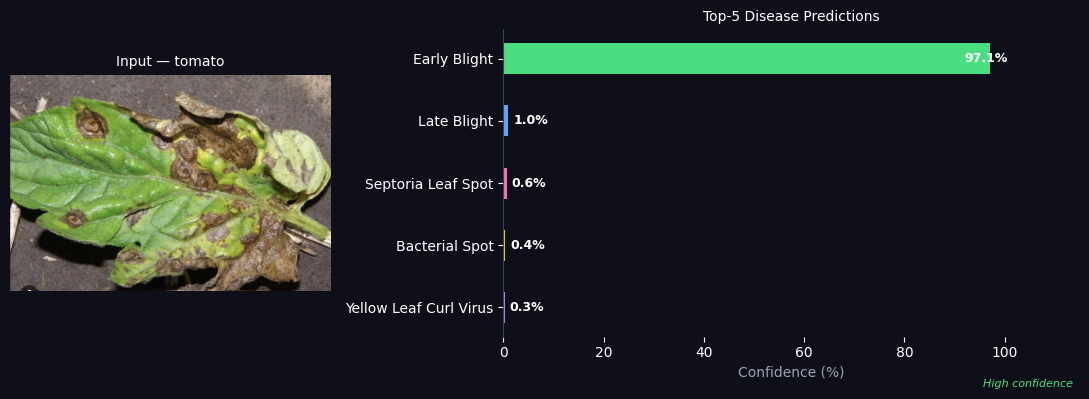


🌿  tomato_eb.png  (crop: tomato)
    #    Disease                                      Conf
    ────────────────────────────────────────────────────────
    #1   Early Blight                                97.1%
    #2   Late Blight                                  1.0%
    #3   Septoria Leaf Spot                           0.6%
    #4   Bacterial Spot                               0.4%
    #5   Yellow Leaf Curl Virus                       0.3%


In [20]:
# User provides crop name → model predicts only among that
# crop's valid diseases (masked). Fully self-contained.


import json, torch, numpy as np, matplotlib.pyplot as plt, cv2
from pathlib import Path
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
from google.colab import drive

drive.mount('/content/drive')

# Config
DRIVE_ROOT   = Path('/content/drive/MyDrive/CropClassifier_v2')
MODEL_DIR    = DRIVE_ROOT / 'models' / 'stage2_disease'
SAVE_MINI    = MODEL_DIR / 'efficientnet_b0_disease_mini.pt'
IDX_MAP_PATH = MODEL_DIR / 'crop_disease_idx_map.json'

IMG_SIZE    = 224
NORM_MEAN   = (0.5, 0.5, 0.5)
NORM_STD    = (0.5, 0.5, 0.5)
TOP_K       = 5

IMAGE_PATH  = '/content/tomato_eb.png'   # ← change this
CROP_NAME   = 'tomato'                      # ← user-selected crop

# Load model + maps
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ckpt         = torch.load(SAVE_MINI, map_location=device)
class_to_idx = ckpt['class_to_idx']          # bundled during training
idx_to_class = {v: k for k, v in class_to_idx.items()}
NUM_CLASSES  = len(class_to_idx)

with open(IDX_MAP_PATH) as f:
    crop_disease_idx_map = json.load(f)

import timm
model = timm.create_model('efficientnet_b0', pretrained=False,
                           num_classes=NUM_CLASSES, drop_rate=0.0)
model.load_state_dict(ckpt['model_state'])
model = model.to(device).eval()
print(f'✅  Model loaded — epoch {ckpt["epoch"]} | val macro F1 = {ckpt["val_macro_f1"]:.4f}')

# Validate crop selection
if CROP_NAME not in crop_disease_idx_map:
    available = sorted(crop_disease_idx_map.keys())
    raise ValueError(f'"{CROP_NAME}" not supported. Available crops: {available}')

valid_idxs = crop_disease_idx_map[CROP_NAME]
print(f'    Crop: {CROP_NAME}  →  {len(valid_idxs)} valid disease classes')

# Transform
infer_transform = A.Compose([
    A.Resize(256, 256, interpolation=cv2.INTER_CUBIC),
    A.CenterCrop(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=NORM_MEAN, std=NORM_STD),
    ToTensorV2(),
])

# Masked prediction
def predict_masked(image_path, crop_name, top_k=TOP_K):
    img_pil = Image.open(image_path).convert('RGB')
    tensor  = infer_transform(image=np.array(img_pil))['image'].unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(tensor)[0]

    # Mask out all classes not valid for this crop
    valid_idxs_t = torch.tensor(crop_disease_idx_map[crop_name], device=device)
    masked_logits = torch.full_like(logits, float('-inf'))
    masked_logits[valid_idxs_t] = logits[valid_idxs_t]

    probs = torch.softmax(masked_logits, dim=0).cpu()
    top_probs, top_idxs = probs.topk(min(top_k, len(valid_idxs_t)))

    results = [(idx_to_class[i.item()], p.item()) for i, p in zip(top_idxs, top_probs)]
    return img_pil, results

def plot_prediction(img_pil, results, image_path, crop_name):
    fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(11, 4),
                                          gridspec_kw={'width_ratios': [1, 1.8]})
    for ax in (ax_img, ax_bar): ax.set_facecolor('#0f0f1a')
    fig.patch.set_facecolor('#0f0f1a')

    ax_img.imshow(img_pil); ax_img.axis('off')
    ax_img.set_title(f'Input — {crop_name}', color='white', fontsize=10)

    colors = ['#4ade80', '#60a5fa', '#f472b6', '#facc15', '#a78bfa']
    labels = [d.split('__', 1)[1].replace('_', ' ').title() for d, _ in results]
    values = [p * 100 for _, p in results]

    ax_bar.barh(labels[::-1], values[::-1],
                color=colors[:len(results)][::-1], height=0.5)
    for i, v in enumerate(values[::-1]):
        ax_bar.text(min(v+1, 92), i, f'{v:.1f}%',
                    va='center', color='white', fontsize=9, fontweight='bold')

    ax_bar.set_xlim(0, 115)
    ax_bar.set_title(f'Top-{len(results)} Disease Predictions', color='white', fontsize=10)
    ax_bar.tick_params(colors='white')
    ax_bar.spines[['top','right','bottom']].set_visible(False)
    ax_bar.spines['left'].set_color('#374151')
    ax_bar.set_xlabel('Confidence (%)', color='#9ca3af')

    top_conf   = values[0]
    conf_label = ('High confidence' if top_conf >= 90 else
                  'Moderate'        if top_conf >= 60 else 'Low — treat with caution')
    conf_color = '#4ade80' if top_conf >= 90 else '#facc15' if top_conf >= 60 else '#f87171'
    fig.text(0.98, 0.02, conf_label, ha='right',
             color=conf_color, fontsize=8, style='italic')

    plt.tight_layout(); plt.show()

    print(f'\n🌿  {Path(image_path).name}  (crop: {crop_name})')
    print(f'    {"#":<3}  {"Disease":<40}  {"Conf":>7}')
    print(f'    {"─"*56}')
    for rank, (disease, prob) in enumerate(results, 1):
        display_name = disease.split('__', 1)[1].replace('_', ' ').title()
        print(f'    #{rank:<2}  {display_name:<40}  {prob*100:>6.1f}%')

# Run
img_pil, results = predict_masked(IMAGE_PATH, CROP_NAME)
plot_prediction(img_pil, results, IMAGE_PATH, CROP_NAME)